In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# Set visual style for plots
sns.set_theme(style="whitegrid")

In [11]:
# Load the dataset
# Ensure 'Social_Network_Ads.csv' is in the same folder as your notebook
df = pd.read_csv('Social_Network_Ads.csv')

# Features: Age (Index 0) and EstimatedSalary (Index 1)
# Target: Purchased (Index 3)
X = df.iloc[:, [0, 1]].values
y = df.iloc[:, 2].values

# Display first 5 rows to verify loading
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [13]:
# Split into Training (75%) and Test (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [15]:
# Initialize Logistic Regression
classifier = LogisticRegression(random_state=0)

# Train the model
classifier.fit(X_train, y_train)

# Predict the test set results
y_pred = classifier.predict(X_test)

In [17]:
# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy

# Display Results
print(f"--- Confusion Matrix Elements ---")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"\n--- Performance Metrics ---")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")

--- Confusion Matrix Elements ---
True Positives (TP): 24
False Positives (FP): 3
True Negatives (TN): 65
False Negatives (FN): 8

--- Performance Metrics ---
Accuracy:   0.8900
Error Rate: 0.1100
Precision:  0.8889
Recall:     0.7500


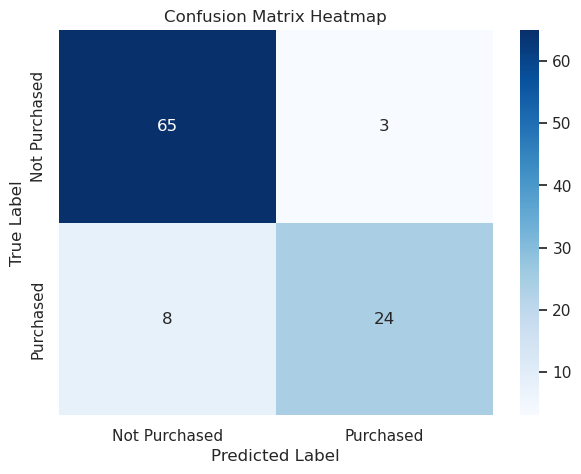

In [19]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchased', 'Purchased'], 
            yticklabels=['Not Purchased', 'Purchased'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()